## Flagging Vendor Invoices for Manual Review
Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.
- Manual invoice review is time-consuming and does not scale with transaction volume.
- Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
- An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Connect to the inventory SQLite database
db_path = Path.cwd() / "Data" / "inventory.db"
if not db_path.exists():
    db_path = Path.cwd().parent / "Data" / "inventory.db"
if not db_path.exists():
    raise FileNotFoundError("Could not find Data/inventory.db. Run this notebook from the project root or notebooks folder.")

conn = sqlite3.connect(db_path)

In [3]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn,
)
tables

,name
0,begin_inventory
1,end_inventory
2,purchase_prices
3,purchases
4,vendor_invoice


In [4]:
for table in tables['name']:
    print('Table name',table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

Table name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


Table name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [5]:
po_summary_df = pd.read_sql_query(
    """
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(
            julianday(p.ReceivingDate) -
            julianday(p.PODate)
        ) AS avg_receiving_delay
    FROM purchases p

    WHERE
        p.Quantity IS NOT NULL
        AND p.Dollars IS NOT NULL
        AND p.PODate IS NOT NULL
        AND p.ReceivingDate IS NOT NULL

    GROUP BY p.PONumber
    """,
    conn
)

po_summary_df

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271
...,...,...,...,...,...
5538,13657,3,253,3844.39,4.870968
5539,13658,111,14115,102949.38,5.016349
5540,13659,13,338,2492.20,4.735294
5541,13660,12,195,2599.66,4.611111


In [6]:
invoice_features_df = pd.read_sql_query(
    """
    SELECT
        vi.PONumber,
        vi.Quantity AS invoice_quantity,
        vi.Dollars AS invoice_dollars,
        vi.Freight,
        (
            julianday(vi.InvoiceDate) -
            julianday(vi.PODate)
        ) AS days_po_to_invoice,
        (
            julianday(vi.PayDate) -
            julianday(vi.InvoiceDate)
        ) AS days_to_pay
    FROM vendor_invoice vi
    WHERE
        vi.Quantity IS NOT NULL
        AND vi.Dollars IS NOT NULL
        AND vi.Freight IS NOT NULL
        AND vi.InvoiceDate IS NOT NULL
        AND vi.PODate IS NOT NULL
        AND vi.PayDate IS NOT NULL
    """,
    conn
)

invoice_features_df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


In [7]:
final_invoice_df = pd.read_sql_query(
    """
    WITH purchase_agg AS (
        SELECT
            p.PONumber,
            COUNT(DISTINCT p.Brand) AS total_brands,
            SUM(p.Quantity) AS total_item_quantity,
            SUM(p.Dollars) AS total_item_dollars,
            AVG(
                julianday(p.ReceivingDate) -
                julianday(p.PODate)
            ) AS avg_receiving_delay

        FROM purchases p

        WHERE
            p.Quantity IS NOT NULL
            AND p.Dollars IS NOT NULL
            AND p.ReceivingDate IS NOT NULL
            AND p.PODate IS NOT NULL

        GROUP BY p.PONumber
    )

    SELECT
        vi.PONumber,
        vi.Quantity AS invoice_quantity,
        vi.Dollars AS invoice_dollars,
        vi.Freight,
        (
            julianday(vi.InvoiceDate) -
            julianday(vi.PODate)
        ) AS days_po_to_invoice,

        (
            julianday(vi.PayDate) -
            julianday(vi.InvoiceDate)
        ) AS days_to_pay,

        pa.total_brands,
        pa.total_item_quantity,
        pa.total_item_dollars,
        pa.avg_receiving_delay

    FROM vendor_invoice vi

    LEFT JOIN purchase_agg pa
        ON vi.PONumber = pa.PONumber

    WHERE
        vi.Quantity IS NOT NULL
        AND vi.Dollars IS NOT NULL
        AND vi.Freight IS NOT NULL
        AND vi.InvoiceDate IS NOT NULL
        AND vi.PODate IS NOT NULL
        AND vi.PayDate IS NOT NULL
    """,
    conn
)

final_invoice_df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [8]:
final_invoice_df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [9]:
final_invoice_df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

In [10]:
def create_invoice_risk_label(row): 
    #Invoice total mismatch with item-level total
    if(abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1
    
    #Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
    return 0
final_invoice_df["flag_invoice"] = final_invoice_df.apply(create_invoice_risk_label, axis = 1)
final_invoice_df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

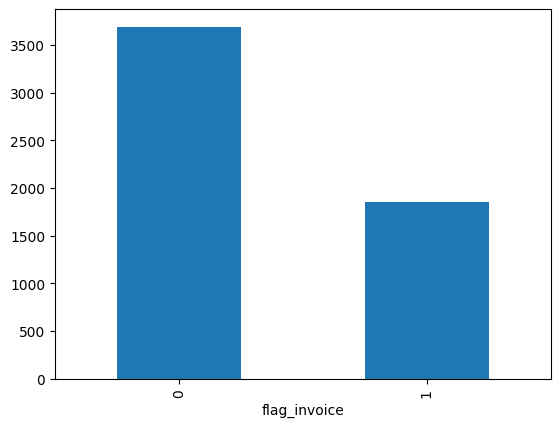

In [11]:
final_invoice_df['flag_invoice'].value_counts().plot(kind = "bar")

In [12]:
final_invoice_df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


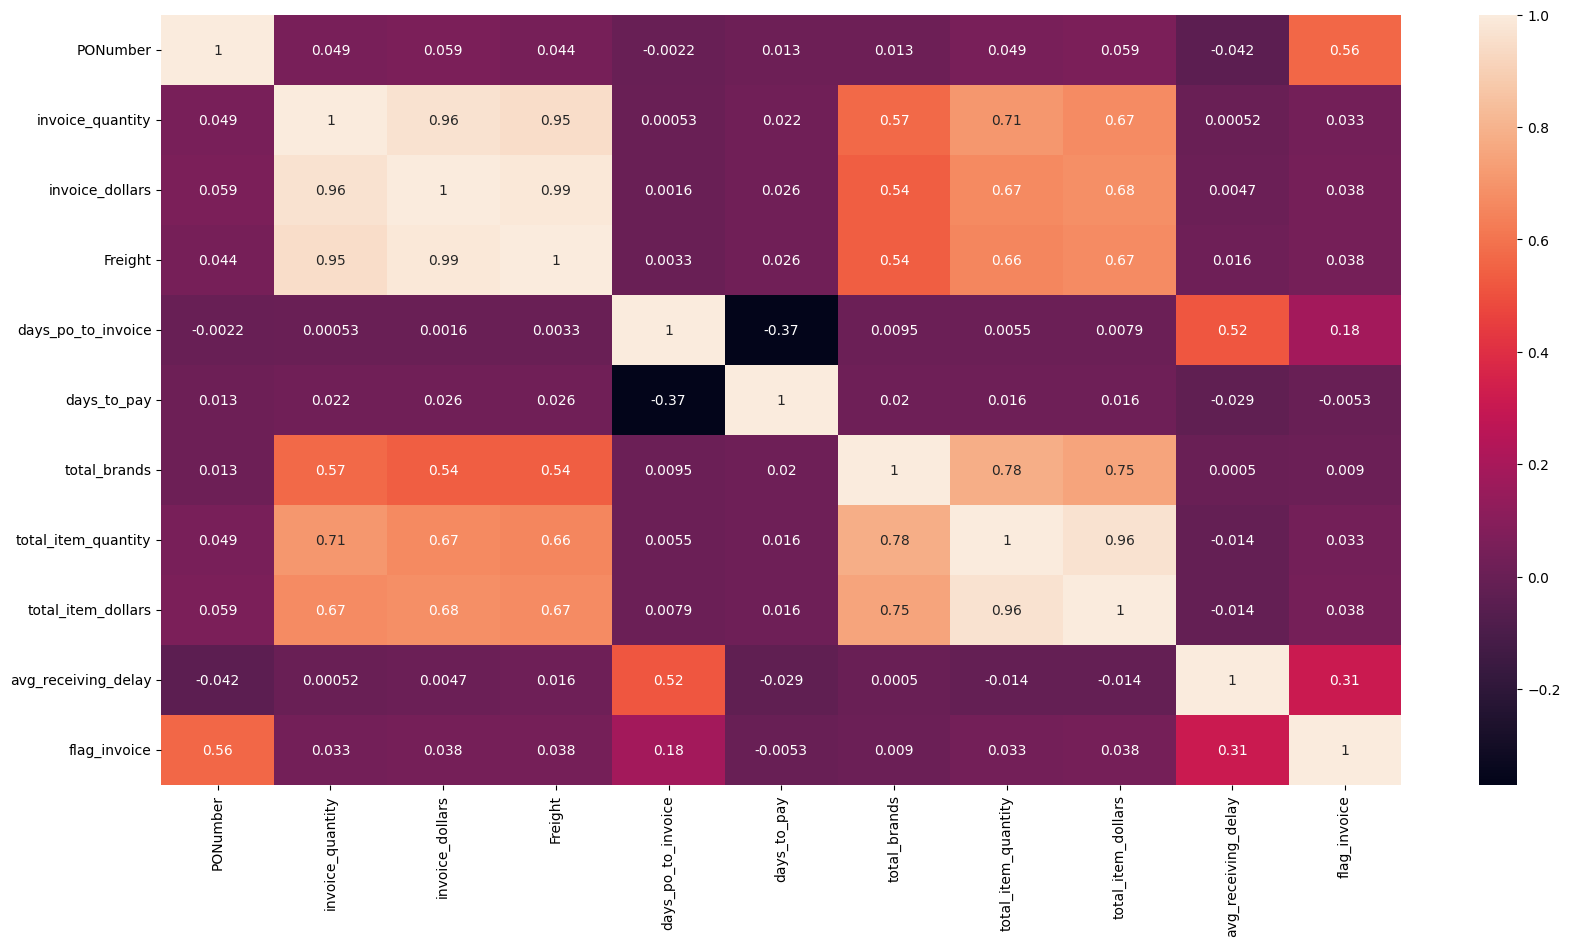

In [13]:
plt.figure(figsize=(20,10))
numeric_invoice_df = final_invoice_df.select_dtypes(include="number")
sns.heatmap(numeric_invoice_df.corr(), annot=True)
plt.show()

In [14]:
flagged = final_invoice_df[final_invoice_df['flag_invoice'] == 1]
normal = final_invoice_df[final_invoice_df['flag_invoice'] == 0]

In [15]:
significant_features = []
non_significant_features = []
results = []

In [16]:
metrics = ['invoice_quantity', 'invoice_dollars','Freight', 'days_po_to_invoice', 'days_to_pay', 'total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay']

In [17]:
from scipy.stats import ttest_ind
for metric in metrics:

    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()
    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": flagged_mean.round(2),
            "normal_mean": normal_mean.round(2),
            "p_value": p_value.round(3)
        })
    else:
        non_significant_features.append(metric)

pd.DataFrame(results)

,metric,flagged_mean,normal_mean,p_value
0,invoice_quantity,6728.28,5723.55,0.021
1,invoice_dollars,65600.61,54302.64,0.008
2,Freight,334.02,276.89,0.008
3,days_po_to_invoice,17.23,16.02,0.000
4,total_item_quantity,6728.28,5723.55,0.021
5,total_item_dollars,65600.61,54302.64,0.008
6,avg_receiving_delay,8.47,7.27,0.000


In [18]:
non_significant_features

['days_to_pay', 'total_brands']

In [19]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [20]:
X = final_invoice_df[['invoice_quantity', 'invoice_dollars','Freight', 'days_po_to_invoice', 'total_brands', 'total_item_quantity', 'total_item_dollars']]
Y = final_invoice_df['flag_invoice']

In [21]:
X

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_brands,total_item_quantity,total_item_dollars
0,6,214.26,3.47,14.0,1,6,214.26
1,15,140.55,8.57,16.0,2,15,140.55
2,5,106.60,4.61,16.0,1,5,106.60
3,10100,137483.78,2935.20,23.0,81,10100,137483.78
4,1935,15527.25,429.20,14.0,29,1935,15527.25
...,...,...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,2,223,6823.18
5539,4617,37300.48,186.50,18.0,110,24747,149007.56
5540,9848,202815.78,932.95,11.0,5,180,2559.72
5541,24747,149007.56,819.54,14.0,83,43240,318075.65


In [22]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,total_brands,total_item_quantity,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,16.0,41.0,6059.0,58073.0
std,14453.0,140234.0,714.0,3.0,77.0,14453.0,140234.0
min,1.0,4.0,0.0,9.0,1.0,1.0,4.0
25%,83.0,968.0,5.0,14.0,3.0,83.0,968.0
50%,423.0,4765.0,25.0,16.0,7.0,423.0,4765.0
75%,5100.0,44587.0,230.0,19.0,46.0,5100.0,44587.0
max,141660.0,1660436.0,8468.0,23.0,807.0,141660.0,1660436.0


In [23]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y,
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [26]:
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000
    ),

    'Decision Tree Classifier': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest Classifier': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
}

for model_name, model in models.items():
    if model_name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(x_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, x_test_data, y_test_data, model_name):
    preds = model.predict(x_test_data)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds, zero_division=0)
    recall = recall_score(y_test_data, preds, zero_division=0)
    f1 = f1_score(y_test_data, preds, zero_division=0)

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
    }

# Evaluate All Models
results = []
for model_name, model in models.items():
    if model_name == 'Logistic Regression':
        result = evaluate_model(model, X_test_scaled, y_test, model_name)
    else:
        result = evaluate_model(model, x_test, y_test, model_name)
    results.append(result)

# Create Results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='F1 Score',
    ascending=False
)

results_df

In [28]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best Model : {best_model_name}")
print(
    f"Accuracy   : "
    f"{results_df.iloc[0]['Accuracy'] * 100:.2f}%"
)
print(
    f"Precision  : "
    f"{results_df.iloc[0]['Precision'] * 100:.2f}%"
)
print(
    f"Recall     : "
    f"{results_df.iloc[0]['Recall'] * 100:.2f}%"
)
print(
    f"F1 Score   : "
    f"{results_df.iloc[0]['F1 Score'] * 100:.2f}%"
)

Best Model : Random Forest Classifier
Accuracy   : 86.93%
Precision  : 91.51%
Recall     : 67.03%
F1 Score   : 77.38%


In [39]:
if hasattr(best_model, "feature_importances_"):
    model_importance = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    model_importance = abs(best_model.coef_[0])
else:
    raise AttributeError(f"{best_model_name} does not expose feature importances or coefficients.")

model_importance

array([0.16306275, 0.188625  , 0.16904526, 0.20186533, 0.27740166])

In [40]:
feature_importance = pd.DataFrame({
    "feature": x_train.columns,
    "importance": model_importance
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
4,total_item_dollars,0.277402
3,total_item_quantity,0.201865
1,invoice_dollars,0.188625
2,Freight,0.169045
0,invoice_quantity,0.163063


In [41]:
selected_features = [
    'invoice_quantity',
    'invoice_dollars',
    'Freight',
    'total_item_quantity',
    'total_item_dollars',
]

X_selected = final_invoice_df[selected_features]
y_selected = final_invoice_df['flag_invoice']

In [42]:
x_train_selected, x_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y_selected,
    test_size=0.2,
    random_state=42,
    stratify=y_selected,
)

selected_rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
selected_rf_model.fit(x_train_selected, y_train_selected)
evaluate_model(selected_rf_model, x_test_selected, y_test_selected, 'Selected Feature Random Forest')


{'Model': 'Selected Feature Random Forest',
 'Accuracy': 0.8719567177637512,
 'Precision': 0.9285714285714286,
 'Recall': 0.6675675675675675,
 'F1 Score': 0.7767295597484277}

In [43]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "criterion": ['gini', 'entropy']
}

In [44]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=0,
    n_jobs=-1
)

grid_search.fit(x_train_selected, y_train_selected)

evaluate_model(grid_search.best_estimator_, x_test_selected, y_test_selected, 'Tuned Random Forest')

{'Model': 'Tuned Random Forest',
 'Accuracy': 0.8845807033363391,
 'Precision': 0.9548872180451128,
 'Recall': 0.6864864864864865,
 'F1 Score': 0.7987421383647799}

In [45]:
from sklearn.metrics import confusion_matrix

confusion_matrix(
    y_test_selected,
    grid_search.best_estimator_.predict(x_test_selected),
)

array([[727,  12],
       [116, 254]])

In [46]:
confusion_matrix(
    y_test_selected,
    selected_rf_model.predict(x_test_selected),
)

array([[720,  19],
       [123, 247]])

In [47]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}